In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from scipy.spatial import cKDTree
from shapely.geometry import Point


In [2]:
# ### Calculate distance to neaerest park for each census tract centroid
from scipy.spatial import cKDTree
from shapely.geometry import Point

In [4]:
# Use OSMnx to get park locations in Philadelphia
gdfhealth = gpd.read_file("../../data/philadelphia-neighborhoods.geojson")

health = ox.features_from_polygon(
    gdf.unary_union,
    tags={'healthcare': ['hospital', 'pharmacy','clinic', 'dentist', 'emergency', 'nursing_home']}
)



print(f"✅ Found {len(health)} health in Philadelphia")
print(f"   Total park area: {health.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample health:")
print(health[['name', 'healthcare']].head(10))


# Keep only essential columns for saving
health_clean = health[['geometry', 'name', 'healthcare']].copy()

# Handle any NaN names
health_clean['name'] = health_clean['name'].fillna('Unnamed clinic')

# Save cleaned version
health_clean.to_file("../../data/philadelphia_healths_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(health_clean)} parks to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull parks dataset has {len(health.columns)} columns")
print(f"Available columns: {health.columns.tolist()[:10]}...")  # Show first 10


NameError: name 'gdf' is not defined

In [68]:
# Get census tract centroids
gdfhealth = gdfhealth.to_crs(2272)
health = health.to_crs(2272)

tract_centroids = gdfhealth.copy()
tract_centroids['geometry'] = gdfhealth.geometry.centroid

# Get park boundaries (or centroids for small parks)
healthpoints = health.geometry.representative_point()

# Build spatial index
health_coords = np.array([(p.x, p.y) for p in healthpoints])
clinic = cKDTree(health_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = clinic.query(tract_coords)

# Add distance (in feet for EPSG:2272)
gdfhealth['health_distance_ft'] = distances

In [69]:
gdfhealth

,Name,geometry,health_distance_ft
0,LAWNDALE,"POLYGON ((2714137.892 272366.707, 2713426.534 ...",1432.227751
1,ASTON_WOODBRIDGE,"POLYGON ((2735802.018 274324.97, 2735800.534 2...",2310.917381
2,CARROLL_PARK,"POLYGON ((2675560.441 244654.627, 2677415.636 ...",1209.747909
3,CHESTNUT_HILL,"POLYGON ((2678326.974 284516.702, 2678343.131 ...",2071.920886
4,BURNHOLME,"POLYGON ((2713510.573 279081.81, 2713537.172 2...",1693.075220
...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((2696909.715 227036.446, 2696794.44 2...",499.743523
154,GARDEN_COURT,"POLYGON ((2679336.637 235986.096, 2679212.449 ...",2163.461842
155,WISSAHICKON_HILLS,"POLYGON ((2676788.178 266688.084, 2676641.185 ...",1168.390591
156,DEARNLEY_PARK,"POLYGON ((2667977.162 268619.475, 2668319.62 2...",2822.167374


In [70]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = gdfhealth['health_distance_ft'].min()
max_dist = gdfhealth['health_distance_ft'].max()

gdfhealth['health_proximity_score'] = 1 - (gdfhealth['health_distance_ft'] - min_dist) / (max_dist - min_dist)

gdfhealth

# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

,Name,geometry,health_distance_ft,health_proximity_score
0,LAWNDALE,"POLYGON ((2714137.892 272366.707, 2713426.534 ...",1432.227751,0.871489
1,ASTON_WOODBRIDGE,"POLYGON ((2735802.018 274324.97, 2735800.534 2...",2310.917381,0.788306
2,CARROLL_PARK,"POLYGON ((2675560.441 244654.627, 2677415.636 ...",1209.747909,0.892550
3,CHESTNUT_HILL,"POLYGON ((2678326.974 284516.702, 2678343.131 ...",2071.920886,0.810931
4,BURNHOLME,"POLYGON ((2713510.573 279081.81, 2713537.172 2...",1693.075220,0.846795
...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((2696909.715 227036.446, 2696794.44 2...",499.743523,0.959764
154,GARDEN_COURT,"POLYGON ((2679336.637 235986.096, 2679212.449 ...",2163.461842,0.802265
155,WISSAHICKON_HILLS,"POLYGON ((2676788.178 266688.084, 2676641.185 ...",1168.390591,0.896466
156,DEARNLEY_PARK,"POLYGON ((2667977.162 268619.475, 2668319.62 2...",2822.167374,0.739907


In [55]:
## SOCIAL SERVICES

In [71]:
# Use OSMnx to get park locations in Philadelphia
gdf = gpd.read_file("../../data/philly_neighborhoods.geojson")

service = ox.features_from_polygon(
    gdf.unary_union,
    tags={'amenity': ['post_office', 'social_facility','fire_station', 'library', 'police', 'childcare']}
)



print(f"✅ Found {len(service)} service in Philadelphia")
print(f"   Total service area: {service.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample health:")
print(service[['name', 'amenity']].head(10))


# Keep only essential columns for saving
service_clean = health[['geometry', 'name', 'amenity']].copy()

# Handle any NaN names
service_clean['name'] = service_clean['name'].fillna('Unnamed clinic')

# Save cleaned version
service_clean.to_file("../../data/philadelphia_services_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(service_clean)} services to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull service dataset has {len(service.columns)} columns")
print(f"Available columns: {service.columns.tolist()[:10]}...")  # Show first 10


C:\Users\kalmanj\AppData\Local\Temp\ipykernel_39424\2451729029.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf.unary_union,


✅ Found 644 service in Philadelphia
   Total service area: 0 acres

Sample health:
                                                     name          amenity
element id                                                                
node    357371754       Chestnut Hill Station Post Office      post_office
        357372188  Holmesburg Finance Station Post Office      post_office
        357372206                       Sacred Heart Home  social_facility
        357372451     East Germantown Station Post Office      post_office
        357372809          Germantown Station Post Office      post_office
        357373001               Logan Station Post Office      post_office
        357373123                     Mayfair Post Office      post_office
        357373188     North Philadelphia West Post Office      post_office
        357373289          Mount Airy Station Post Office      post_office
        357373320        Hunting Park Station Post Office      post_office
✅ Saved 259 servi

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_39424\2451729029.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"   Total service area: {service.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres


In [72]:
# Get census tract centroids
gdf = gdf.to_crs(2272)
service = service.to_crs(2272)

tract_centroids = gdf.copy()
tract_centroids['geometry'] = gdf.geometry.centroid

# Get park boundaries (or centroids for small parks)
servicepoints = service.geometry.representative_point()

# Build spatial index
service_coords = np.array([(p.x, p.y) for p in servicepoints])
serve = cKDTree(service_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = serve.query(tract_coords)

# Add distance (in feet for EPSG:2272)
gdf['service_distance_ft'] = distances

In [73]:
gdf

,Name,geometry,service_distance_ft
0,LAWNDALE,"POLYGON ((2714137.892 272366.707, 2713426.534 ...",821.967431
1,ASTON_WOODBRIDGE,"POLYGON ((2735802.018 274324.97, 2735800.534 2...",2450.231498
2,CARROLL_PARK,"POLYGON ((2675560.441 244654.627, 2677415.636 ...",906.067479
3,CHESTNUT_HILL,"POLYGON ((2678326.974 284516.702, 2678343.131 ...",1345.606915
4,BURNHOLME,"POLYGON ((2713510.573 279081.81, 2713537.172 2...",1391.496696
...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((2696909.715 227036.446, 2696794.44 2...",1836.495141
154,GARDEN_COURT,"POLYGON ((2679336.637 235986.096, 2679212.449 ...",727.954727
155,WISSAHICKON_HILLS,"POLYGON ((2676788.178 266688.084, 2676641.185 ...",1299.743280
156,DEARNLEY_PARK,"POLYGON ((2667977.162 268619.475, 2668319.62 2...",3182.162053


In [74]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = gdf['service_distance_ft'].min()
max_dist = gdf['service_distance_ft'].max()

gdf['service_proximity_score'] = 1 - (gdf['service_distance_ft'] - min_dist) / (max_dist - min_dist)
gdf


# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

,Name,geometry,service_distance_ft,service_proximity_score
0,LAWNDALE,"POLYGON ((2714137.892 272366.707, 2713426.534 ...",821.967431,0.892003
1,ASTON_WOODBRIDGE,"POLYGON ((2735802.018 274324.97, 2735800.534 2...",2450.231498,0.646258
2,CARROLL_PARK,"POLYGON ((2675560.441 244654.627, 2677415.636 ...",906.067479,0.879310
3,CHESTNUT_HILL,"POLYGON ((2678326.974 284516.702, 2678343.131 ...",1345.606915,0.812973
4,BURNHOLME,"POLYGON ((2713510.573 279081.81, 2713537.172 2...",1391.496696,0.806047
...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((2696909.715 227036.446, 2696794.44 2...",1836.495141,0.738886
154,GARDEN_COURT,"POLYGON ((2679336.637 235986.096, 2679212.449 ...",727.954727,0.906192
155,WISSAHICKON_HILLS,"POLYGON ((2676788.178 266688.084, 2676641.185 ...",1299.743280,0.819895
156,DEARNLEY_PARK,"POLYGON ((2667977.162 268619.475, 2668319.62 2...",3182.162053,0.535791


In [81]:
merged = gdf[["Name", "geometry", "service_distance_ft", "service_proximity_score"]].merge(
    gdfhealth.drop(columns="geometry"),
    on="Name",
    how="left"
)

merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=gdf.crs)
merged

,Name,geometry,service_distance_ft,service_proximity_score,health_distance_ft,health_proximity_score
0,LAWNDALE,"POLYGON ((2714137.892 272366.707, 2713426.534 ...",821.967431,0.892003,1432.227751,0.871489
1,ASTON_WOODBRIDGE,"POLYGON ((2735802.018 274324.97, 2735800.534 2...",2450.231498,0.646258,2310.917381,0.788306
2,CARROLL_PARK,"POLYGON ((2675560.441 244654.627, 2677415.636 ...",906.067479,0.879310,1209.747909,0.892550
3,CHESTNUT_HILL,"POLYGON ((2678326.974 284516.702, 2678343.131 ...",1345.606915,0.812973,2071.920886,0.810931
4,BURNHOLME,"POLYGON ((2713510.573 279081.81, 2713537.172 2...",1391.496696,0.806047,1693.075220,0.846795
...,...,...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((2696909.715 227036.446, 2696794.44 2...",1836.495141,0.738886,499.743523,0.959764
154,GARDEN_COURT,"POLYGON ((2679336.637 235986.096, 2679212.449 ...",727.954727,0.906192,2163.461842,0.802265
155,WISSAHICKON_HILLS,"POLYGON ((2676788.178 266688.084, 2676641.185 ...",1299.743280,0.819895,1168.390591,0.896466
156,DEARNLEY_PARK,"POLYGON ((2667977.162 268619.475, 2668319.62 2...",3182.162053,0.535791,2822.167374,0.739907


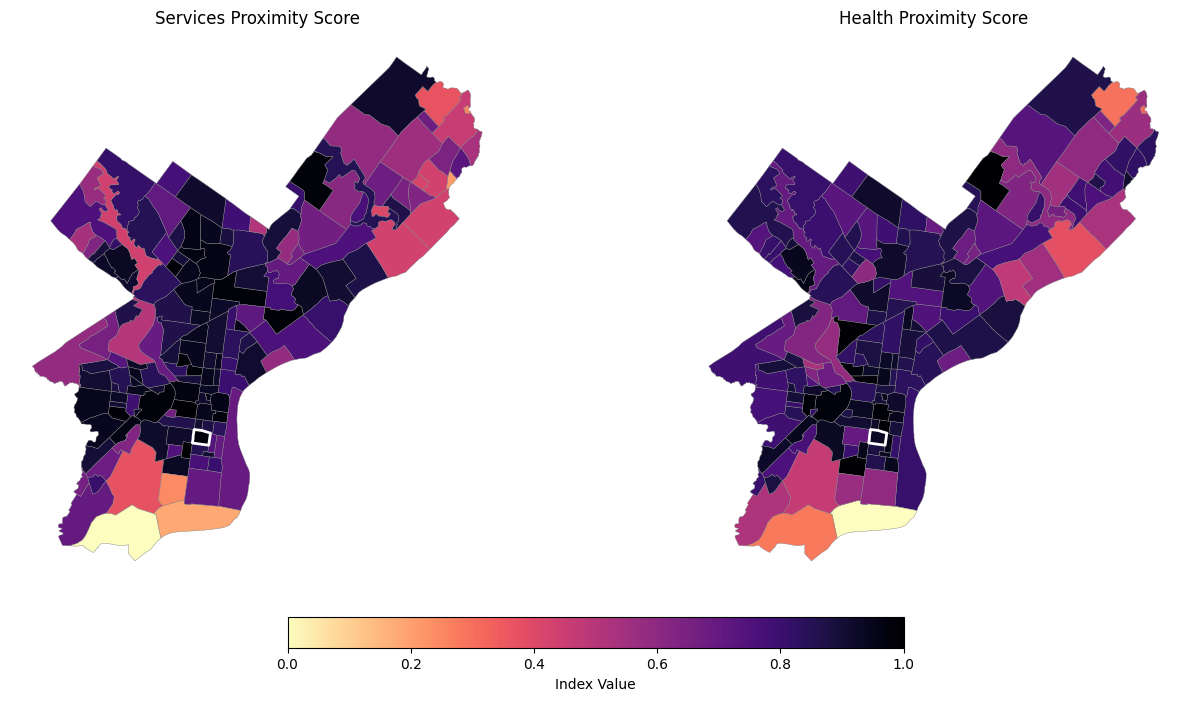

In [113]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

east_passyunk = merged[merged["Name"] == "PASSYUNK_SQUARE"]

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    merged["service_proximity_score"].min(),
    merged["health_proximity_score"].min(),
)

vmax = max(
    merged["service_proximity_score"].max(),
    merged["health_proximity_score"].max(),
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "magma_r"  # safer built-in cmap

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax1, ax2, = axes

# -------------------------
# MAP 1 – Age 65+ Rate (Inverse)
# -------------------------
merged.plot(
    column="service_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)
# Highlight East Passyunk tracts
east_passyunk.plot(ax=ax1, facecolor='none', edgecolor="white", linewidth=2)

ax1.set_title("Services Proximity Score")
ax1.axis("off")

# -------------------------
# MAP 2 – Disability Rate (Inverse)
# -------------------------
merged.plot(
    column="health_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)
east_passyunk.plot(ax=ax2, facecolor='none', edgecolor="white", linewidth=2)

ax2.set_title("Health Proximity Score")
ax2.axis("off")


# -------------------------
# SHARED COLORBAR
# -------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal",
                    fraction=0.05, pad=0.05)
cbar.set_label("Index Value")

plt.show()

In [114]:
merged[merged['Name'].str.contains('PASSYUNK', case=False, na=False)]


,Name,geometry,service_distance_ft,service_proximity_score,health_distance_ft,health_proximity_score
105,WEST_PASSYUNK,"POLYGON ((2687671.164 227872.85, 2690474.474 2...",1774.990835,0.748168,2215.702575,0.797320
107,EAST_PASSYUNK,"POLYGON ((2692095.99 225898.045, 2692411.37 22...",1087.039625,0.851997,1349.852453,0.879287
152,PASSYUNK_SQUARE,"POLYGON ((2695723.128 228111.539, 2695664.839 ...",233.236983,0.980857,773.578817,0.933841


In [117]:
hoodgdf = gpd.read_file("../green_space/hoodgdf.gpkg")


In [118]:

# Step 2 — merge bike index
hoodgdf = hoodgdf.merge(
    merged[["Name", "health_proximity_score"]],
    on="Name",
    how="left"
)

# Step 3 — merge curb density index
hoodgdf = hoodgdf.merge(
    merged[["Name", "service_proximity_score"]],
    on="Name",
    how="left"
)

hoodgdf

,Name,sidewalk_index,bike_index,cartway_density_index,ndvi_score,park_proximity_score,tree_score,geometry,health_proximity_score,service_proximity_score
0,LAWNDALE,0.981667,0.201329,0.633628,0.356519,0.886946,0.000000,"POLYGON ((-75.08616 40.05013, -75.08893 40.044...",0.871489,0.892003
1,ASTON_WOODBRIDGE,0.946746,0.201768,0.682118,0.560973,0.437272,0.000000,"POLYGON ((-75.0086 40.05369, -75.00861 40.0535...",0.788306,0.646258
2,CARROLL_PARK,0.964426,0.190563,0.735923,0.266218,0.823277,0.064336,"POLYGON ((-75.22673 39.9772, -75.22022 39.9742...",0.892550,0.879310
3,CHESTNUT_HILL,0.950545,0.022636,0.439744,0.804823,0.713442,0.000000,"POLYGON ((-75.21278 40.08637, -75.21272 40.086...",0.810931,0.812973
4,BURNHOLME,0.923102,0.145879,0.864792,0.566354,0.759824,0.044473,"POLYGON ((-75.08768 40.06861, -75.08758 40.068...",0.846795,0.806047
...,...,...,...,...,...,...,...,...,...,...
153,DICKINSON_NARROWS,0.918205,0.096523,0.814234,0.104201,0.906231,0.000000,"POLYGON ((-75.15244 39.92716, -75.15294 39.924...",0.959764,0.738886
154,GARDEN_COURT,1.012222,0.365182,0.926294,0.329481,0.950068,0.000000,"POLYGON ((-75.21415 39.95312, -75.21469 39.950...",0.802265,0.906192
155,WISSAHICKON_HILLS,0.997497,0.436108,0.889194,0.587372,0.722529,0.000000,"POLYGON ((-75.2201 40.03757, -75.22064 40.0372...",0.896466,0.819895
156,DEARNLEY_PARK,0.814339,0.206014,0.811131,0.735065,0.692587,0.139064,"POLYGON ((-75.25136 40.04355, -75.2501 40.0446...",0.739907,0.535791


In [119]:
hoodgdf.to_file("hoodgdf.gpkg", layer="hood", driver="GPKG")


## percentile graphs 

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import percentileofscore
import plotly.graph_objects as go

### --------------------------
### 1. Define variables
### --------------------------

landuse_vars = [
    "service_proximity_score",
    "health_proximity_score",
    "sidewalk_index",
    "bike_index",
    "cartway_density_index",
    "ndvi_score",
    "park_proximity_score",
    "tree_score"
]

# Copy to avoid modifying main gdf
df_land = hoodgdf.copy()

### --------------------------
### 2. Compute percentiles
### --------------------------

for var in landuse_vars:
    df_land[var + "_pct"] = df_land[var].apply(
        lambda x: np.nan if pd.isna(x) else percentileofscore(df_land[var].dropna(), x)
    )

# Extract East Passyunk tracts
ep_land = df_land[df_land["Name"].str.contains("PASSYUNK", case=False)]

# Clean selection
ep_land = ep_land[["Name"] + [v+"_pct" for v in landuse_vars]]

### --------------------------
### 3. Interactive Plotly chart
### --------------------------

fig = go.Figure()

x_labels = [v.replace("_", " ").title() for v in landuse_vars]

for _, row in ep_land.iterrows():
    name = row["Name"]
    values = row[[v+"_pct" for v in landuse_vars]].values
    
    fig.add_trace(go.Bar(
        x=x_labels,
        y=values,
        name=name,
        text=[f"{v:.1f}" if not pd.isna(v) else "Missing" for v in values],
        textposition="outside",
        hovertemplate="<b>%{x}</b><br>Percentile: %{y:.1f}<extra>" + name + "</extra>"
    ))

fig.update_layout(
    title="Citywide Percentile Profile — East Passyunk Land Use & Service Variables",
    yaxis_title="Percentile (0–100)",
    barmode='group',
    bargap=0.12,
    template="plotly_white",
    height=650,
    xaxis_tickangle=-45,
)

fig.show()


NameError: name 'hoodgdf' is not defined